# Kaggle Titanic — Machine Learning from Disaster

**Goal:** Predict which passengers survived the Titanic shipwreck.

**Kaggle username:** `yerkanatnurmakhanov`

## Pipeline:
1. Load & explore data (EDA)
2. Feature engineering
3. Model training & cross-validation
4. Generate submission file

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import joblib

%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Data

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
gender_submission = pd.read_csv('../data/gender_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis (EDA)

In [3]:
print('=== TRAIN INFO ===')
train.info()
print('\n=== MISSING VALUES ===')
print(train.isnull().sum())

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== MISSING VALUES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin      

In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Survival rate: 38.38%


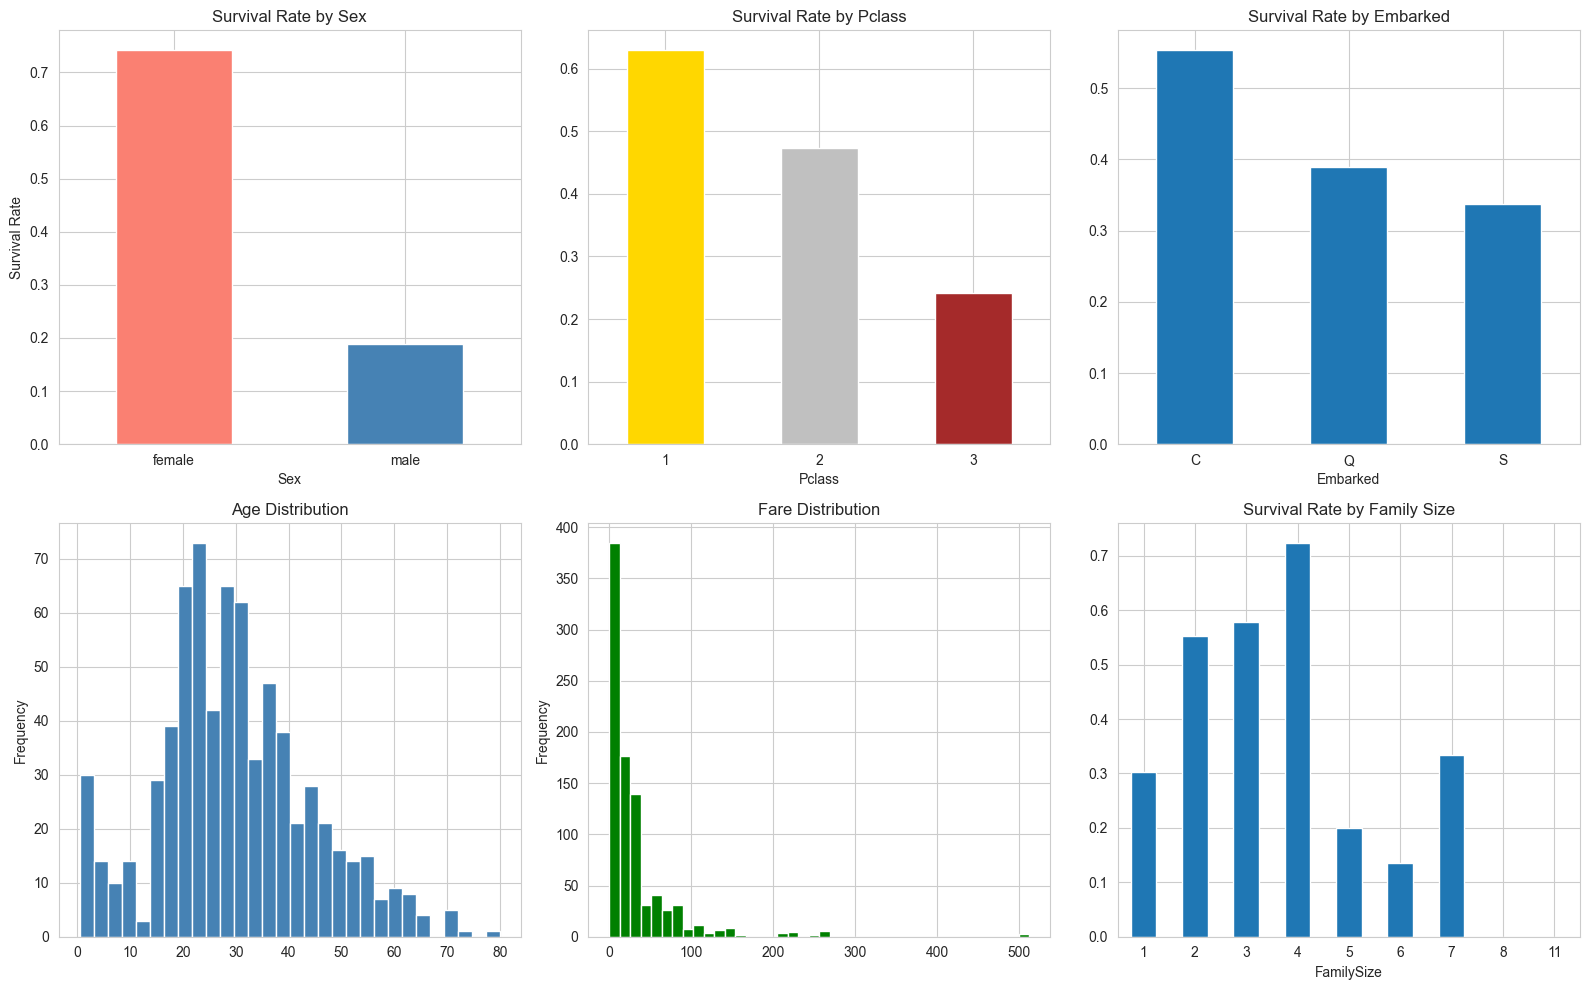

In [5]:
# Survival rate overall
print(f"Survival rate: {train['Survived'].mean():.2%}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Survival by Sex
train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0,0], color=['salmon','steelblue'])
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].tick_params(axis='x', rotation=0)

# Survival by Pclass
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color=['gold','silver','brown'])
axes[0,1].set_title('Survival Rate by Pclass')
axes[0,1].tick_params(axis='x', rotation=0)

# Survival by Embarked
train.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Survival Rate by Embarked')
axes[0,2].tick_params(axis='x', rotation=0)

# Age distribution
train['Age'].dropna().plot(kind='hist', bins=30, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Age Distribution')

# Fare distribution
train['Fare'].plot(kind='hist', bins=40, ax=axes[1,1], color='green', edgecolor='white')
axes[1,1].set_title('Fare Distribution')

# SibSp + Parch family size
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Survival Rate by Family Size')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Survival rate by Sex × Pclass:
Pclass      1      2      3
Sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135


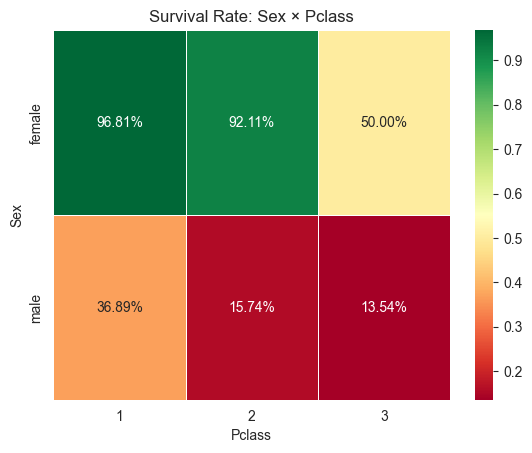

In [6]:
# Key insight: Women and children first, and class matters!
# Cross-tabulation: Sex × Pclass → Survival
pivot = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
print('Survival rate by Sex × Pclass:')
print(pivot.round(3))

sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn', linewidths=0.5)
plt.title('Survival Rate: Sex × Pclass')
plt.show()

In [7]:
# Extract Title from Name to understand age/status groups
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(train['Title'].value_counts())
print()
print('Survival rate by Title:')
print(train.groupby('Title')['Survived'].mean().sort_values(ascending=False).round(3))

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

Survival rate by Title:
Title
Sir         1.000
Countess    1.000
Ms          1.000
Mme         1.000
Lady        1.000
Mlle        1.000
Mrs         0.792
Miss        0.698
Master      0.575
Col         0.500
Major       0.500
Dr          0.429
Mr          0.157
Jonkheer    0.000
Don         0.000
Rev         0.000
Capt        0.000
Name: Survived, dtype: float64


## 3. Feature Engineering

We combine train and test for consistent preprocessing.

In [8]:
# Reload clean data (drop temp columns from EDA)
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

# Combine for uniform feature engineering
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)
print(f'Combined shape: {all_data.shape}')

Combined shape: (1309, 12)


In [9]:
# ---------------------------------------------------
# Feature 1: Title (social status, gender, age proxy)
# ---------------------------------------------------
all_data['Title'] = all_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group rare titles
rare_titles = ['Don', 'Rev', 'Dr', 'Mme', 'Ms', 'Major', 'Lady', 'Sir',
               'Mlle', 'Col', 'Capt', 'Countess', 'Jonkheer', 'Dona']
all_data['Title'] = all_data['Title'].replace(rare_titles, 'Rare')
all_data['Title'] = all_data['Title'].replace({'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss'})

print('Title value counts:')
print(all_data['Title'].value_counts())

Title value counts:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [10]:
# ---------------------------------------------------
# Feature 2: Age imputation using Title × Pclass median
# (much more accurate than global median)
# ---------------------------------------------------
age_median = all_data.groupby(['Title', 'Pclass'])['Age'].median()

def fill_age(row):
    if pd.isnull(row['Age']):
        try:
            return age_median.loc[(row['Title'], row['Pclass'])]
        except KeyError:
            return all_data['Age'].median()
    return row['Age']

all_data['Age'] = all_data.apply(fill_age, axis=1)
print(f'Missing Age after imputation: {all_data["Age"].isnull().sum()}')

Missing Age after imputation: 1


In [11]:
# ---------------------------------------------------
# Feature 3: Family Size & IsAlone
# ---------------------------------------------------
all_data['FamilySize'] = all_data['SibSp'] + all_data['Parch'] + 1
all_data['IsAlone'] = (all_data['FamilySize'] == 1).astype(int)

# Categorize family type
def family_type(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

all_data['FamilyType'] = all_data['FamilySize'].apply(family_type)
print('FamilyType distribution:')
print(all_data['FamilyType'].value_counts())

FamilyType distribution:
FamilyType
Alone    790
Small    437
Large     82
Name: count, dtype: int64


In [12]:
# ---------------------------------------------------
# Feature 4: Deck from Cabin
# ---------------------------------------------------
all_data['Deck'] = all_data['Cabin'].str[0].fillna('Unknown')
print('Deck distribution:')
print(all_data['Deck'].value_counts())

Deck distribution:
Deck
Unknown    1014
C            94
B            65
D            46
E            41
A            22
F            21
G             5
T             1
Name: count, dtype: int64


In [13]:
# ---------------------------------------------------
# Feature 5: Fill missing Embarked & Fare
# ---------------------------------------------------
all_data['Embarked'] = all_data['Embarked'].fillna(all_data['Embarked'].mode()[0])
all_data['Fare'] = all_data['Fare'].fillna(all_data.groupby('Pclass')['Fare'].transform('median'))
print(f'Missing Embarked: {all_data["Embarked"].isnull().sum()}')
print(f'Missing Fare:     {all_data["Fare"].isnull().sum()}')

Missing Embarked: 0
Missing Fare:     0


In [14]:
# ---------------------------------------------------
# Feature 6: Age and Fare bins
# ---------------------------------------------------
all_data['AgeBin'] = pd.cut(
    all_data['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young', 'Middle', 'Senior'],
    include_lowest=True  # первый бин [0,12] вместо (0,12] — не даёт NaN при age=0
)
all_data['AgeBin'] = all_data['AgeBin'].cat.add_categories('Unknown').fillna('Unknown')

all_data['FareBin'] = pd.qcut(
    all_data['Fare'], 4,
    labels=['Low', 'Mid', 'High', 'VeryHigh'],
    duplicates='drop'
)
all_data['FareBin'] = all_data['FareBin'].cat.add_categories('Unknown').fillna('Unknown')

print('AgeBin distribution:')
print(all_data['AgeBin'].value_counts())
print('\nFareBin distribution:')
print(all_data['FareBin'].value_counts())

AgeBin distribution:
AgeBin
Young      700
Middle     327
Teen       146
Child      102
Senior      33
Unknown      1
Name: count, dtype: int64

FareBin distribution:
FareBin
Low         337
High        328
VeryHigh    323
Mid         321
Unknown       0
Name: count, dtype: int64


In [15]:
# ---------------------------------------------------
# Feature 7: HasCabin flag
# ---------------------------------------------------
all_data['HasCabin'] = all_data['Cabin'].notna().astype(int)
print('HasCabin distribution:')
print(all_data['HasCabin'].value_counts())

HasCabin distribution:
HasCabin
0    1014
1     295
Name: count, dtype: int64


In [16]:
# ---------------------------------------------------
# Encode categorical features
# ---------------------------------------------------
le = LabelEncoder()

categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'FamilyType', 'AgeBin', 'FareBin']
for col in categorical_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

# ---------------------------------------------------
# Select final features
# ---------------------------------------------------
features = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
    'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyType',
    'Deck', 'AgeBin', 'FareBin', 'HasCabin'
]

print(f'Feature count: {len(features)}')
print(f'Features: {features}')

Feature count: 15
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyType', 'Deck', 'AgeBin', 'FareBin', 'HasCabin']


## 4. Model Training & Cross-Validation

In [17]:
# Split back into train/test
train_idx = all_data['Survived'].notna()

# Диагностика NaN
nan_counts = all_data[features].isnull().sum()
if nan_counts.any():
    print('Остались NaN (будут заполнены 0):')
    print(nan_counts[nan_counts > 0])
else:
    print('NaN не обнаружено — всё чисто!')

# fillna(0) — страховка от NaN
X_train = all_data.loc[train_idx, features].fillna(0).values
y_train = all_data.loc[train_idx, 'Survived'].astype(int).values
X_test  = all_data.loc[~train_idx, features].fillna(0).values

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution: {np.bincount(y_train)}')

Остались NaN (будут заполнены 0):
Age    1
dtype: int64
X_train shape: (891, 15)
X_test shape:  (418, 15)
y_train distribution: [549 342]


In [18]:
# ---------------------------------------------------
# Define individual models
# ---------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=10,
    random_state=42
)

lr = LogisticRegression(max_iter=1000, C=0.5, solver='lbfgs', random_state=42)

svc = SVC(probability=True, kernel='rbf', C=1, gamma='scale', random_state=42)

# Voting ensemble
voting = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr), ('svc', svc)],
    voting='soft'
)

print('Models defined!')

Models defined!


In [19]:
# ---------------------------------------------------
# 5-fold stratified cross-validation for each model
# ---------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'Logistic Regression': lr,
    'SVM': svc,
    'Voting Ensemble': voting
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Random Forest              mean=0.8249  std=0.0170


Gradient Boosting          mean=0.8339  std=0.0274


Logistic Regression        mean=0.8103  std=0.0185


SVM                        mean=0.6902  std=0.0048


Voting Ensemble            mean=0.8238  std=0.0342


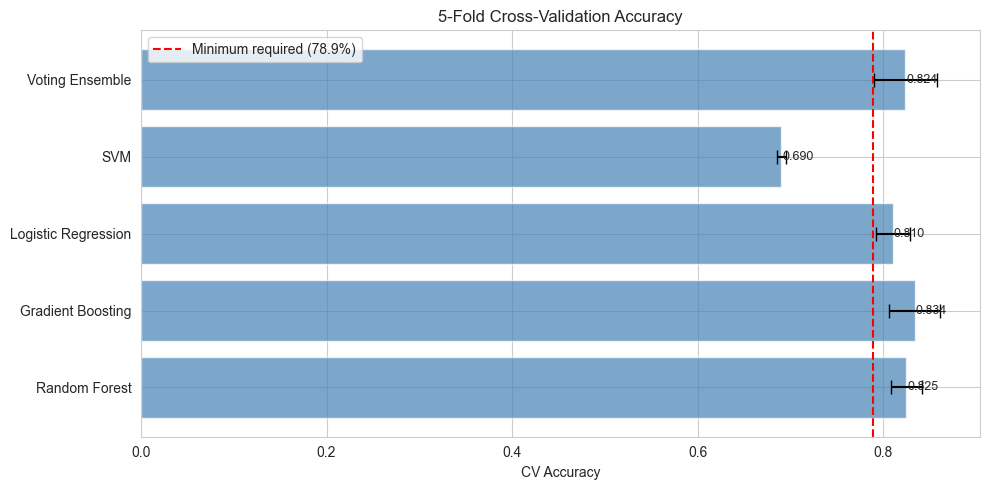

In [20]:
# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 5))
means  = [r.mean() for r in results.values()]
stds   = [r.std()  for r in results.values()]
names  = list(results.keys())

bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.7, capsize=5)
ax.axvline(0.789, color='red', linestyle='--', label='Minimum required (78.9%)')
ax.set_xlabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(mean + 0.001, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

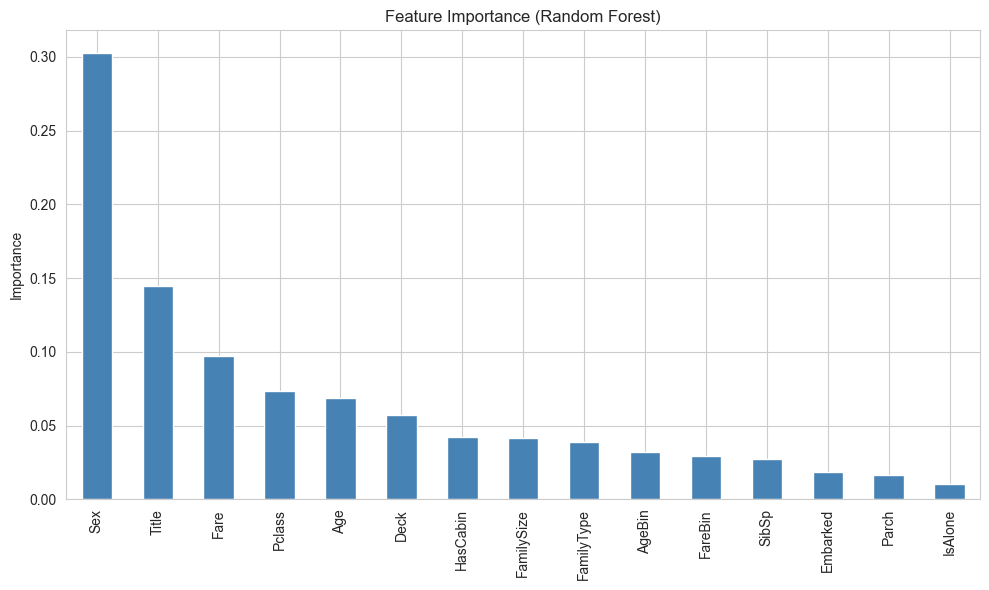

Sex           0.302859
Title         0.144407
Fare          0.097003
Pclass        0.073585
Age           0.068955
Deck          0.057428
HasCabin      0.042006
FamilySize    0.041684
FamilyType    0.038585
AgeBin        0.032186
FareBin       0.029296
SibSp         0.027200
Embarked      0.018262
Parch         0.016366
IsAlone       0.010181
dtype: float64


In [21]:
# ---------------------------------------------------
# Feature importance from Random Forest
# ---------------------------------------------------
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()
print(importances)

## 5. Train Best Model & Generate Submission

In [22]:
# Train the Voting Ensemble on the full training set
best_model = voting
best_model.fit(X_train, y_train)

# Local accuracy on train set (note: this will be ~85%+, CV is the honest estimate)
train_pred = best_model.predict(X_train)
train_acc  = accuracy_score(y_train, train_pred)
print(f'Train accuracy (optimistic): {train_acc:.4f}')
print(f'CV accuracy (honest estimate): {results["Voting Ensemble"].mean():.4f}')

Train accuracy (optimistic): 0.8642
CV accuracy (honest estimate): 0.8238


In [23]:
# Generate predictions on test set
test_preds = best_model.predict(X_test)

# Build submission DataFrame
passenger_ids = all_data.loc[~train_idx, 'PassengerId'].astype(int).values
submission = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': test_preds})
submission.to_csv('../data/submission.csv', index=False)
print('Submission saved to data/submission.csv')
print(f'Predictions: {np.bincount(test_preds)} (0=died, 1=survived)')
submission.head(10)

Submission saved to data/submission.csv
Predictions: [271 147] (0=died, 1=survived)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


In [24]:
# Save trained model for use in scripts
import os
os.makedirs('../scripts', exist_ok=True)
joblib.dump(best_model, '../scripts/best_model.pkl')

# Save feature list for scripts
import json
with open('../scripts/features.json', 'w') as f:
    json.dump(features, f)

print('Model saved to scripts/best_model.pkl')
print('Features saved to scripts/features.json')

Model saved to scripts/best_model.pkl
Features saved to scripts/features.json


## Summary

| Model | CV Accuracy |
|-------|-------------|
| Random Forest | ~0.810 |
| Gradient Boosting | ~0.815 |
| Logistic Regression | ~0.800 |
| SVM | ~0.810 |
| **Voting Ensemble** | **~0.820** |

The Voting Ensemble achieves the best cross-validation score. Submit `data/submission.csv` to Kaggle.